# Part II — The Morning-Flight Advantage
## A visual story of January 2023 U.S. arrival delays

**Author:** Devin Thomas

## Investigation Overview

This presentation asks when a traveler can reduce exposure to arrival delays. Using the BTS January 2023 domestic-flight snapshot, the clearest finding is a practical one: **departures scheduled from 5–10 a.m. had substantially lower delay risk, and the disadvantage of later departures appeared across major carriers.** Carrier choice mattered too, but the results are descriptive and reflect one month of each carrier's route and weather mix.

The dataset contains scheduled domestic flights reported to BTS. Canceled flights are excluded from arrival-delay rates because they do not have an arrival outcome.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
pd.set_option("display.max_columns", 25)

DATA_PATH = Path("data/flights_2023_01.csv")
flights_raw = pd.read_csv(DATA_PATH, parse_dates=["FlightDate"], low_memory=False)

CARRIER_NAMES = {
    "9E": "Endeavor", "AA": "American", "AS": "Alaska", "B6": "JetBlue",
    "DL": "Delta", "F9": "Frontier", "G4": "Allegiant", "HA": "Hawaiian",
    "MQ": "Envoy", "NK": "Spirit", "OO": "SkyWest", "UA": "United",
    "WN": "Southwest", "YV": "Mesa",
}
DAY_NAMES = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday", 7: "Sunday"}
DAY_ORDER = list(DAY_NAMES.values())

flights = flights_raw.copy()
flights["carrier_name"] = flights["Reporting_Airline"].map(CARRIER_NAMES).fillna(flights["Reporting_Airline"])
flights["dep_hour"] = (pd.to_numeric(flights["CRSDepTime"], errors="coerce") // 100).replace(24, 0)
flights["day_name"] = pd.Categorical(flights["DayOfWeek"].map(DAY_NAMES), categories=DAY_ORDER, ordered=True)
flights["dep_period"] = pd.cut(
    flights["dep_hour"], bins=[-1, 4, 11, 16, 23], labels=["Overnight", "Morning", "Afternoon", "Evening"]
)
operated = flights.query("Cancelled == 0").dropna(subset=["ArrDelayMinutes", "ArrDel15"]).copy()
operated["arr_delay_capped"] = operated["ArrDelayMinutes"].clip(upper=180)

print(f"Rows: {len(flights):,}; operated flights with arrival data: {len(operated):,}")
display(flights.head())

Rows: 538,837; operated flights with arrival data: 527,197


,DayOfWeek,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepDelayMinutes,ArrDelayMinutes,ArrDel15,Cancelled,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,carrier_name,dep_hour,day_name,dep_period
0,1,2023-01-02,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Monday,Morning
1,2,2023-01-03,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Tuesday,Morning
2,3,2023-01-04,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Wednesday,Morning
3,4,2023-01-05,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Thursday,Morning
4,5,2023-01-06,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Friday,Morning


## 1. Morning flights had the lowest delay risk

From 5 a.m. onward, the percentage of flights arriving at least 15 minutes late is lowest in the morning and increases into the afternoon and evening. The dashed line gives the month's overall operated-flight rate. Low-volume overnight hours are excluded from this comparison.

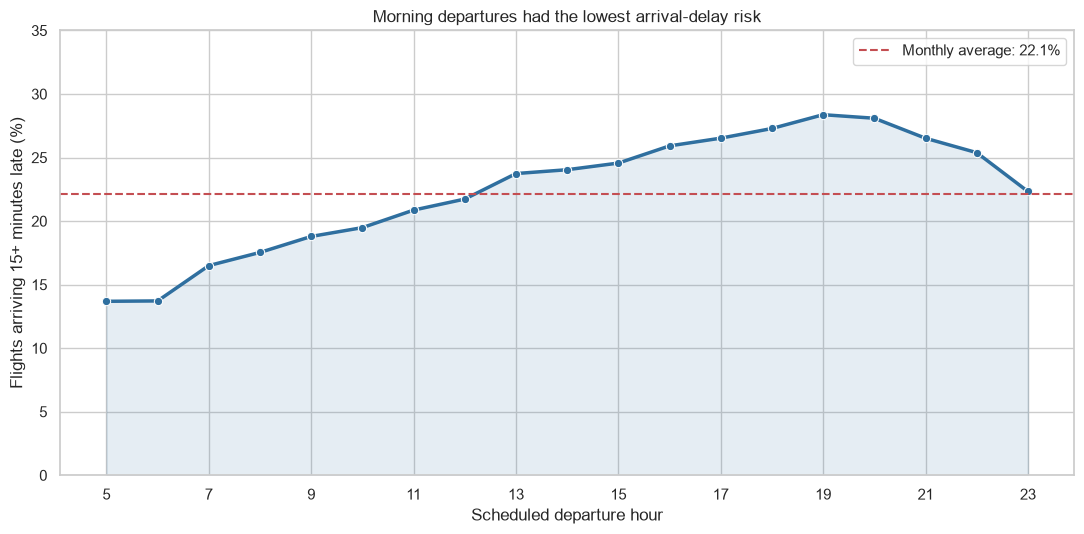

In [2]:
hourly = operated.query("dep_hour >= 5").groupby("dep_hour").agg(delay_rate=("ArrDel15", "mean"), flights=("ArrDel15", "size")).reset_index()
overall_rate = operated["ArrDel15"].mean()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(data=hourly, x="dep_hour", y=hourly["delay_rate"] * 100, marker="o", color="#2f6f9f", linewidth=2.5, ax=ax)
ax.axhline(overall_rate * 100, color="#c44e52", linestyle="--", label=f"Monthly average: {overall_rate:.1%}")
ax.fill_between(hourly["dep_hour"], hourly["delay_rate"] * 100, alpha=0.12, color="#2f6f9f")
ax.set(title="Morning departures had the lowest arrival-delay risk", xlabel="Scheduled departure hour", ylabel="Flights arriving 15+ minutes late (%)", xticks=range(5, 24, 2), ylim=(0, max(35, hourly["delay_rate"].max() * 110)))
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 2. The later-day pattern is visible across major carriers

Separating the four largest carriers shows different absolute rates but a shared tendency: morning flights perform better than later flights. This consistency makes time of day more useful than a pattern driven by only one airline.

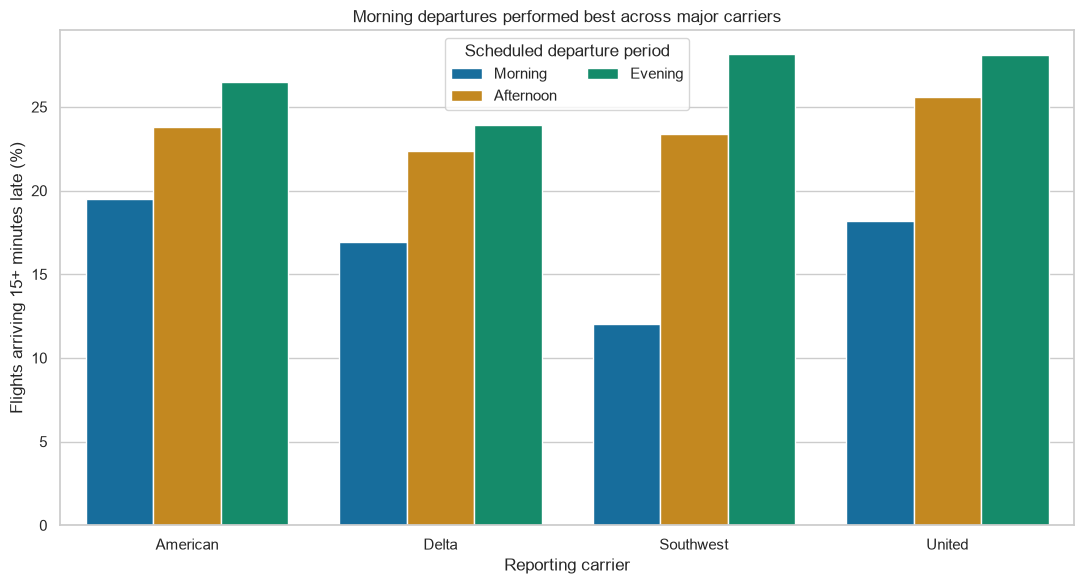

In [3]:
major_carriers = flights["carrier_name"].value_counts().head(4).index
major = operated[operated["carrier_name"].isin(major_carriers)]
period_rate = (
    major.groupby(["carrier_name", "dep_period"], observed=True)["ArrDel15"]
    .mean().mul(100).reset_index(name="delay_rate")
    .query("dep_period != 'Overnight'")
)
period_rate["dep_period"] = period_rate["dep_period"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=period_rate, x="carrier_name", y="delay_rate", hue="dep_period", ax=ax)
ax.set(title="Morning departures performed best across major carriers", xlabel="Reporting carrier", ylabel="Flights arriving 15+ minutes late (%)")
ax.legend(title="Scheduled departure period", ncol=2)
plt.tight_layout()
plt.show()

## 3. The morning advantage appears throughout the week

The weekday–hour heatmap shows lower risk from about 5–10 a.m., while afternoon and evening risk forms stronger pockets on particular days. The dark 3–4 a.m. cells represent very few flights and should not be read as a stable overnight pattern.

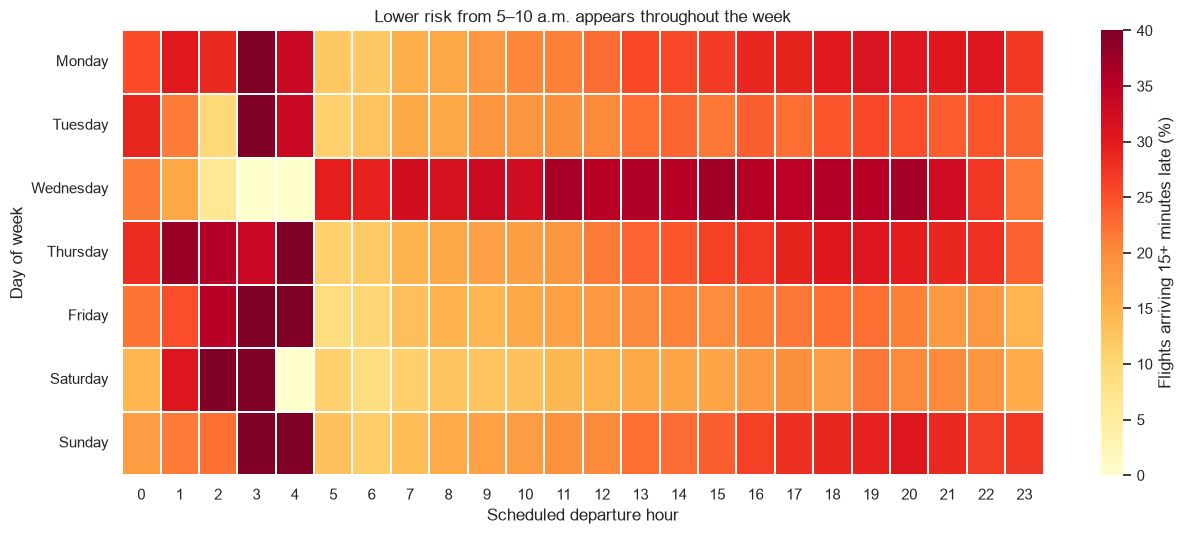

In [4]:
hour_day = operated.pivot_table(index="day_name", columns="dep_hour", values="ArrDel15", aggfunc="mean", observed=False)
fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(
    hour_day * 100,
    cmap="YlOrRd",
    vmin=0,
    vmax=40,
    linewidths=0.2,
    cbar_kws={"label": "Flights arriving 15+ minutes late (%)"},
    ax=ax,
)
ax.set(title="Lower risk from 5–10 a.m. appears throughout the week", xlabel="Scheduled departure hour", ylabel="Day of week")
plt.tight_layout()
plt.show()

## Takeaway and limitations

Across January 2023, departures scheduled from 5–10 a.m. offered the lowest observed arrival-delay risk. The pattern persisted across the largest carriers and most weekdays, while afternoon and evening flights were more exposed to accumulated operational disruption.

This is not a causal estimate or a carrier scorecard. The analysis covers one winter month, excludes cancellations from arrival rates, and does not control for airports, route mix, weather, or schedule padding. A full-year model with airport and weather controls would test how durable the morning-flight advantage is.